In [41]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# Manual Transaction Entry Module

manual_transactions = [
    ['2024-01-05', 'Food', 1200],
    ['2024-01-08', 'Transport', 500],
    ['2024-01-12', 'Entertainment', 2000],
    ['2024-01-15', 'Health', 1500]
]

manual_df = pd.DataFrame(
    manual_transactions,
    columns=['date', 'category', 'amount']
)

manual_df['date'] = pd.to_datetime(manual_df['date'])

print("Manual Transactions")
manual_df

Manual Transactions


,date,category,amount
0,2024-01-05,Food,1200
1,2024-01-08,Transport,500
2,2024-01-12,Entertainment,2000
3,2024-01-15,Health,1500


In [43]:
# Step 1: Generate a large mock dataset
np.random.seed(42)  # For reproducibility

In [44]:

# Step 1: Create a mock dataset
data = {
    'date': pd.date_range(start='2024-01-01', periods=30, freq='D'),
    'category': ['Food', 'Rent', 'Utilities', 'Entertainment'] * 7 + ['Food', 'Rent'],
    'amount': np.random.randint(50, 500, 30)
}

In [45]:
# Step 1A: Create Income Dataset

income_data = {
    'date': pd.date_range(start='2024-01-01', periods=12, freq='MS'),
    'source': [
        'Salary', 'Salary', 'Salary', 'Salary',
        'Salary', 'Salary', 'Salary', 'Salary',
        'Salary', 'Salary', 'Salary', 'Salary'
    ],
    'amount': [
        50000, 50000, 52000, 52000,
        55000, 55000, 55000, 58000,
        58000, 60000, 60000, 60000
    ]
}

income_df = pd.DataFrame(income_data)

print("Income Dataset")
income_df.head()

Income Dataset


,date,source,amount
0,2024-01-01,Salary,50000
1,2024-02-01,Salary,50000
2,2024-03-01,Salary,52000
3,2024-04-01,Salary,52000
4,2024-05-01,Salary,55000


In [46]:
print(df.head())

        date       category  amount  days day_of_week    month
0 2023-01-01  Entertainment     230     0      Sunday  2023-01
1 2023-01-02      Transport     656     1      Monday  2023-01
2 2023-01-03      Utilities     148     2     Tuesday  2023-01
3 2023-01-04      Transport     749     3   Wednesday  2023-01
4 2023-01-05      Transport     165     4    Thursday  2023-01


In [47]:
# Step 1B: Financial Summary

total_income = income_df['amount'].sum()

total_expense = df['amount'].sum()

savings = total_income - total_expense

savings_rate = (savings / total_income) * 100

print(f"Total Income: ₹{total_income:,.2f}")
print(f"Total Expense: ₹{total_expense:,.2f}")
print(f"Total Savings: ₹{savings:,.2f}")
print(f"Savings Rate: {savings_rate:.2f}%")

Total Income: ₹665,000.00
Total Expense: ₹196,140.00
Total Savings: ₹468,860.00
Savings Rate: 70.51%


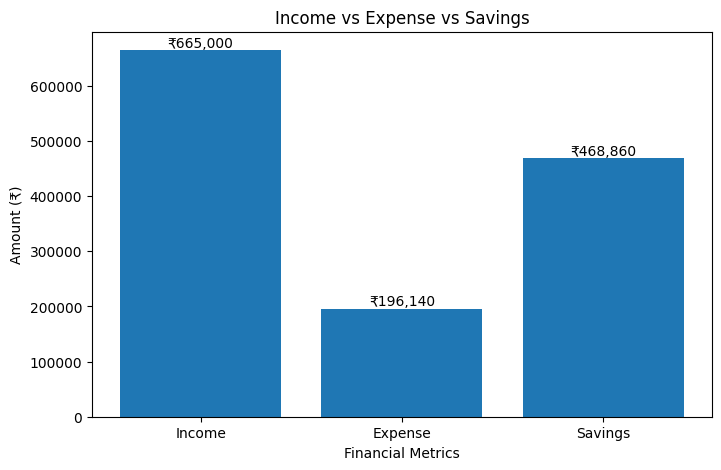

In [48]:
# Step 1C: Income vs Expense vs Savings Visualization

summary = pd.DataFrame({
    'Metric': ['Income', 'Expense', 'Savings'],
    'Amount': [total_income, total_expense, savings]
})

plt.figure(figsize=(8,5))

bars = plt.bar(summary['Metric'], summary['Amount'])

plt.title('Income vs Expense vs Savings')
plt.ylabel('Amount (₹)')
plt.xlabel('Financial Metrics')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'₹{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.show()

In [49]:
df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])
df['days'] = (df['date'] - df['date'].min()).dt.days

# Merge manual transactions
df = pd.concat(
    [df, manual_df],
    ignore_index=True
)

# Recalculate days after merge
df['days'] = (df['date'] - df['date'].min()).dt.days

print("Updated Dataset Shape:", df.shape)

Updated Dataset Shape: (34, 4)


In [50]:
# Step 2A: Budget Limits for Categories

budget_limits = {
    'Food': 40000,
    'Rent': 70000,
    'Utilities': 25000,
    'Entertainment': 20000,
    'Transport': 15000,
    'Health': 10000
}

budget_df = pd.DataFrame(
    list(budget_limits.items()),
    columns=['Category', 'Budget Limit']
)

print("Category Budget Limits")
budget_df

Category Budget Limits


,Category,Budget Limit
0,Food,40000
1,Rent,70000
2,Utilities,25000
3,Entertainment,20000
4,Transport,15000
5,Health,10000


In [51]:
# Step 2B: Budget Monitoring

# Total spending by category
category_spending = df.groupby('category')['amount'].sum().reset_index()

# Rename column
category_spending.columns = ['Category', 'Spent']

# Merge with budget limits
budget_monitor = pd.merge(
    category_spending,
    budget_df,
    on='Category'
)

# Calculate remaining budget
budget_monitor['Remaining'] = (
    budget_monitor['Budget Limit']
    - budget_monitor['Spent']
)

# Status
budget_monitor['Status'] = budget_monitor['Remaining'].apply(
    lambda x: 'Over Budget ⚠️' if x < 0 else 'Within Budget ✅'
)

print("Budget Monitoring Report")
budget_monitor

Budget Monitoring Report


,Category,Spent,Budget Limit,Remaining,Status
0,Entertainment,4206,20000,15794,Within Budget ✅
1,Food,2950,40000,37050,Within Budget ✅
2,Health,1500,10000,8500,Within Budget ✅
3,Rent,2376,70000,67624,Within Budget ✅
4,Transport,500,15000,14500,Within Budget ✅
5,Utilities,2204,25000,22796,Within Budget ✅


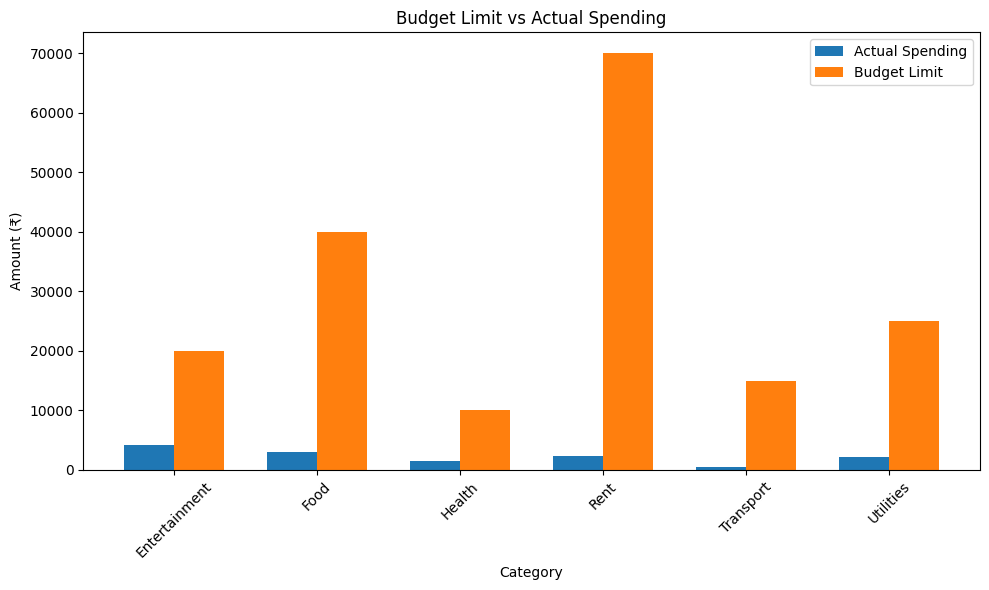

In [52]:
# Step 2C: Budget vs Actual Spending Visualization

plt.figure(figsize=(10,6))

x = np.arange(len(budget_monitor))

width = 0.35

plt.bar(
    x - width/2,
    budget_monitor['Spent'],
    width,
    label='Actual Spending'
)

plt.bar(
    x + width/2,
    budget_monitor['Budget Limit'],
    width,
    label='Budget Limit'
)

plt.xticks(
    x,
    budget_monitor['Category'],
    rotation=45
)

plt.ylabel('Amount (₹)')
plt.xlabel('Category')
plt.title('Budget Limit vs Actual Spending')
plt.legend()

plt.tight_layout()
plt.show()

In [53]:
# Step 3: Budget Alert System

print("========== BUDGET ALERTS ==========\n")

for _, row in budget_monitor.iterrows():

    if row['Remaining'] < 0:
        print(
            f"⚠️ ALERT: {row['Category']} exceeded budget by ₹{abs(row['Remaining']):,.0f}"
        )

    elif row['Remaining'] <= row['Budget Limit'] * 0.10:
        print(
            f"⚠️ WARNING: {row['Category']} has less than 10% budget remaining"
        )

    else:
        print(
            f"✅ {row['Category']} is within budget"
        )

========== BUDGET ALERTS ==========

✅ Entertainment is within budget
✅ Food is within budget
✅ Health is within budget
✅ Rent is within budget
✅ Transport is within budget
✅ Utilities is within budget


In [54]:
# Step 4: Financial Dashboard Summary

predicted_next_month = future_df['amount'].sum()

dashboard = pd.DataFrame({
    'Metric': [
        'Total Income',
        'Total Expenses',
        'Total Savings',
        'Savings Rate (%)',
        'Predicted Next Month Spending'
    ],
    'Value': [
        total_income,
        total_expense,
        savings,
        round(savings_rate, 2),
        round(predicted_next_month, 2)
    ]
})

print("========== FINANCIAL DASHBOARD ==========\n")

dashboard

========== FINANCIAL DASHBOARD ==========



,Metric,Value
0,Total Income,665000.00
1,Total Expenses,196140.00
2,Total Savings,468860.00
3,Savings Rate (%),70.51
4,Predicted Next Month Spending,15189.01


In [55]:
# Step 5: Budget Health Score

total_categories = len(budget_monitor)

within_budget = len(
    budget_monitor[
        budget_monitor['Status'].str.contains('Within Budget')
    ]
)

health_score = (within_budget / total_categories) * 100

print("========== BUDGET HEALTH ==========\n")
print(f"Budget Health Score: {health_score:.0f}/100")

if health_score >= 80:
    print("🟢 Financial Health: Excellent")
elif health_score >= 60:
    print("🟡 Financial Health: Good")
elif health_score >= 40:
    print("🟠 Financial Health: Fair")
else:
    print("🔴 Financial Health: Poor")

========== BUDGET HEALTH ==========

Budget Health Score: 100/100
🟢 Financial Health: Excellent


In [56]:
df

,date,category,amount,days
0,2024-01-01,Food,152,0
1,2024-01-02,Rent,485,1
2,2024-01-03,Utilities,398,2
3,2024-01-04,Entertainment,320,3
4,2024-01-05,Food,156,4
5,2024-01-06,Rent,121,5
6,2024-01-07,Utilities,238,6
7,2024-01-08,Entertainment,70,7
8,2024-01-09,Food,152,8
9,2024-01-10,Rent,171,9


In [57]:
# Step 2: Predict future spending
X = df[['days']]
y = df['amount']

# Train Linear Regression model
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
# Predict spending for the next 10 days
future_days = np.arange(df['days'].max() + 1, df['days'].max() + 11).reshape(-1, 1)
future_predictions = model.predict(future_days)

C:\Users\Ajinkya Mariche\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


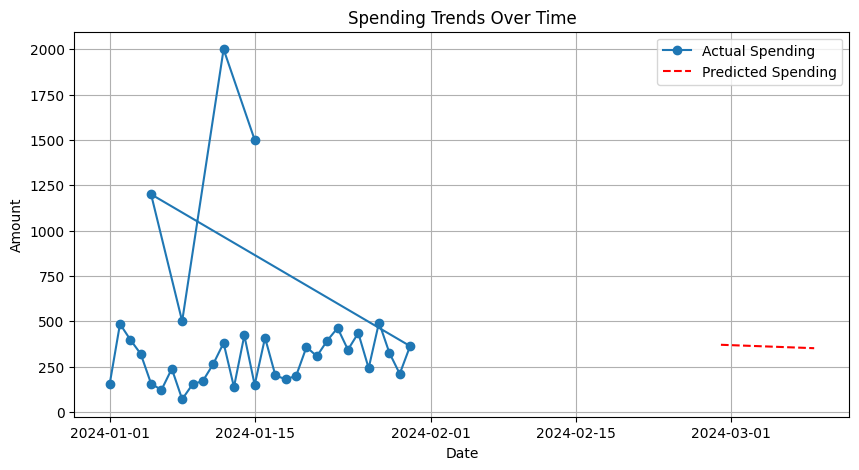

In [59]:
# Step 3: Visualizations
# (a) Spending trends over time
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['amount'], label='Actual Spending', marker='o')
future_dates = [df['date'].max() + pd.Timedelta(days=int(x)) for x in future_days.flatten()]
plt.plot(future_dates, future_predictions, label='Predicted Spending', linestyle='--', color='red')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.title('Spending Trends Over Time')
plt.legend()
plt.grid()
plt.show()

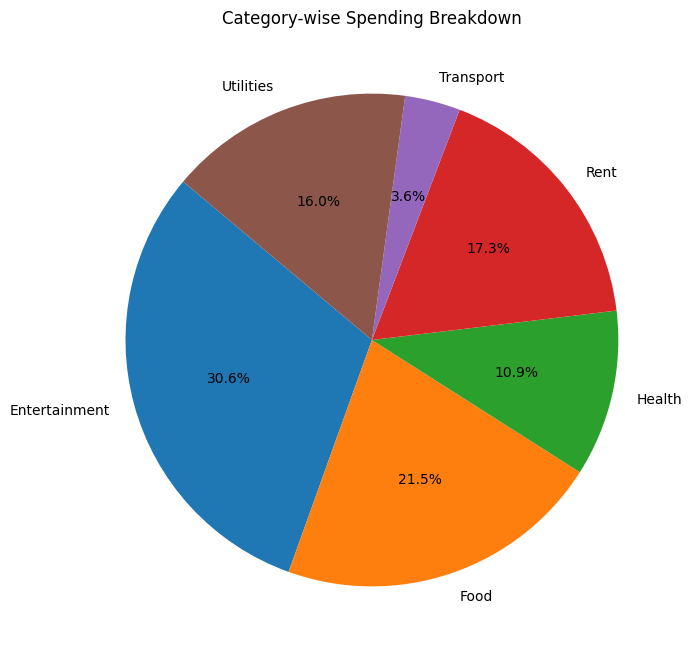

In [60]:
# (b) Category-wise spending breakdown
category_sum = df.groupby('category')['amount'].sum()
plt.figure(figsize=(8, 8))
category_sum.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Category-wise Spending Breakdown')
plt.ylabel('')  # Hide y-label for better appearance
plt.show()

C:\Users\Ajinkya Mariche\AppData\Roaming\Python\Python313\site-packages\pandas\plotting\_matplotlib\core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


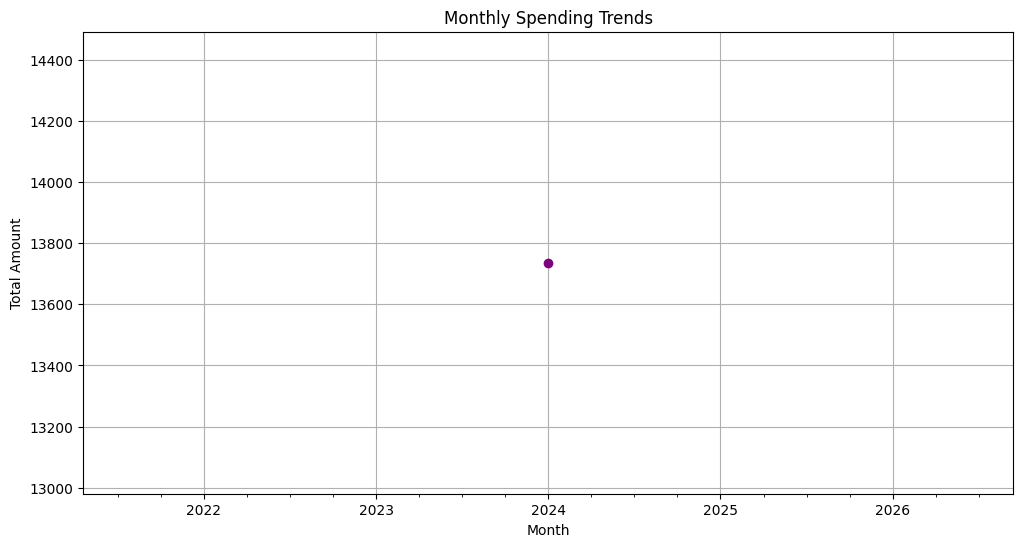

In [61]:
# (c) Monthly spending trends
df['month'] = df['date'].dt.to_period('M')
monthly_sum = df.groupby('month')['amount'].sum()
plt.figure(figsize=(12, 6))
monthly_sum.plot(kind='line', marker='o', color='purple')
plt.title('Monthly Spending Trends')
plt.ylabel('Total Amount')
plt.xlabel('Month')
plt.grid()
plt.show()

C:\Users\Ajinkya Mariche\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


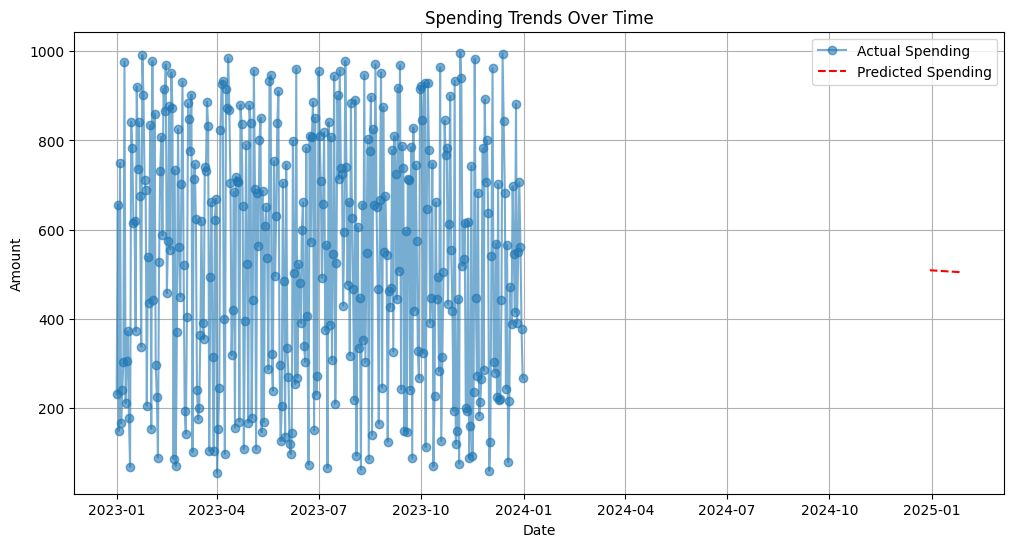

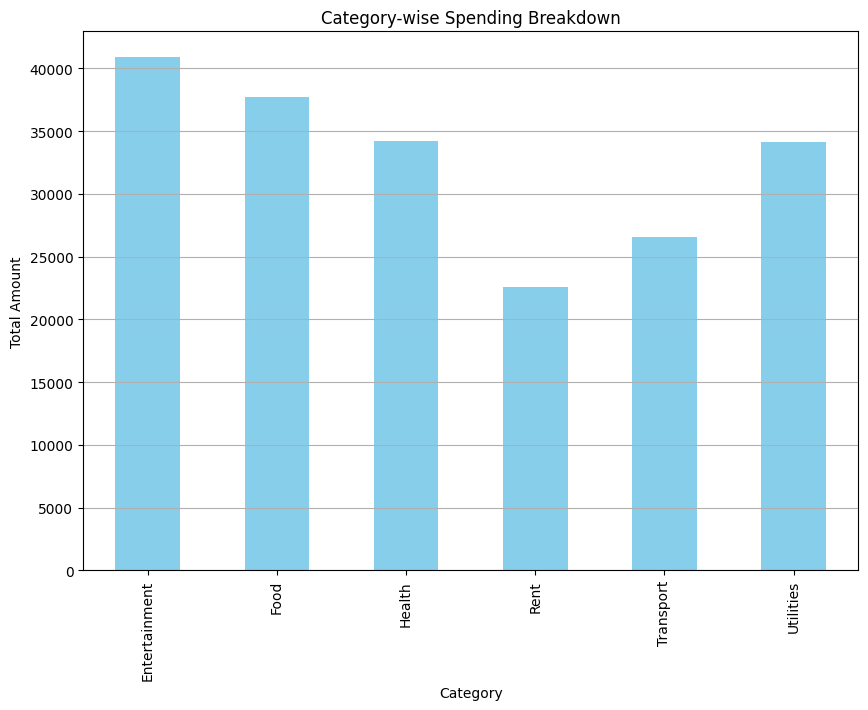

Predicted total spending for the next month: ₹15189.01


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Step 1: Generate a large mock dataset
np.random.seed(42)

categories = ['Food', 'Rent', 'Utilities', 'Entertainment', 'Transport', 'Health']
data = {
    'date': pd.date_range(start='2023-01-01', periods=365, freq='D'),
    'category': np.random.choice(categories, 365),
    'amount': np.random.randint(50, 1000, 365)
}

df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])
df['days'] = (df['date'] - df['date'].min()).dt.days

# Step 2: Predict future spending
X = df[['days']]
y = df['amount']

# Train Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Predict spending for the next 30 days
future_days = np.arange(df['days'].max() + 1, df['days'].max() + 31).reshape(-1, 1)
future_predictions = model.predict(future_days)

# Calculate total predicted spending for the next 30 days
total_predicted_spending = np.sum(future_predictions)

# Step 3: Visualizations
# (a) Spending trends over time
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['amount'], label='Actual Spending', marker='o', alpha=0.6)
future_dates = [df['date'].max() + pd.Timedelta(days=int(x)) for x in future_days.flatten()]
plt.plot(future_dates, future_predictions, label='Predicted Spending', linestyle='--', color='red')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.title('Spending Trends Over Time')
plt.legend()
plt.grid()
plt.show()

# (b) Display category-wise spending breakdown
category_sum = df.groupby('category')['amount'].sum()
plt.figure(figsize=(10, 7))
category_sum.plot(kind='bar', color='skyblue')
plt.title('Category-wise Spending Breakdown')
plt.ylabel('Total Amount')
plt.xlabel('Category')
plt.grid(axis='y')
plt.show()

# Display total predicted spending for the next month
print(f"Predicted total spending for the next month: ₹{total_predicted_spending:.2f}")


Actual Predictions Starts Here

In [63]:
np.random.seed(42)
categories = ['Food', 'Rent', 'Utilities', 'Entertainment', 'Transport', 'Health']
data = {
    'date': pd.date_range(start='2023-01-01', periods=365, freq='D'),
    'category': np.random.choice(categories, 365),
    'amount': np.random.randint(50, 1000, 365)
}

In [64]:
df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])
df['days'] = (df['date'] - df['date'].min()).dt.days



In [65]:
# Train Linear Regression model for predictions
X = df[['days']]
y = df['amount']

In [66]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
future_days = np.arange(df['days'].max() + 1, df['days'].max() + 31).reshape(-1, 1)
future_predictions = model.predict(future_days)

C:\Users\Ajinkya Mariche\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [68]:
# Add Predictions DataFrame
future_dates = [df['date'].max() + pd.Timedelta(days=int(x)) for x in future_days.flatten()]
future_df = pd.DataFrame({
    'date': future_dates,
    'amount': future_predictions,
    'category': 'Predicted'
})
full_df = pd.concat([df, future_df])

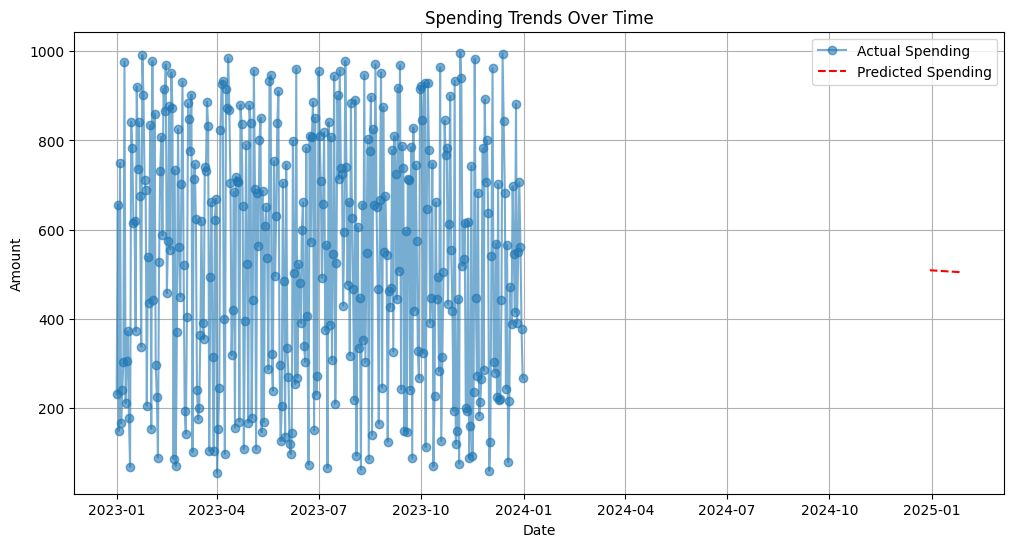

In [69]:
# Visualization 1: Spending Trends with Predictions
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['amount'], label='Actual Spending', marker='o', alpha=0.6)
plt.plot(future_dates, future_predictions, label='Predicted Spending', linestyle='--', color='red')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.title('Spending Trends Over Time')
plt.legend()
plt.grid()
plt.show()

In [70]:
# Visualization 2: Spending Heatmap by Day of the Week and Category
df['day_of_week'] = df['date'].dt.day_name()
heatmap_data = df.pivot_table(index='day_of_week', columns='category', values='amount', aggfunc='sum').fillna(0)


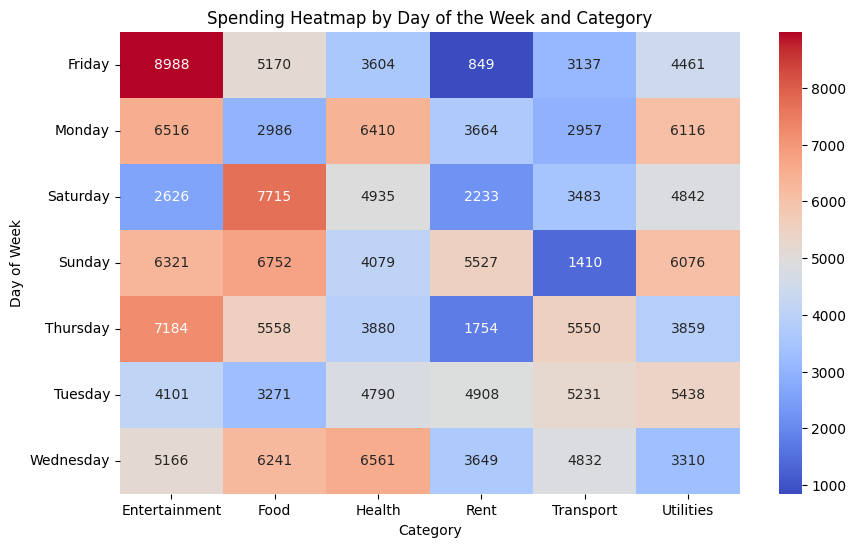

In [71]:
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="coolwarm", cbar=True)
plt.title('Spending Heatmap by Day of the Week and Category')
plt.ylabel('Day of Week')
plt.xlabel('Category')
plt.show()

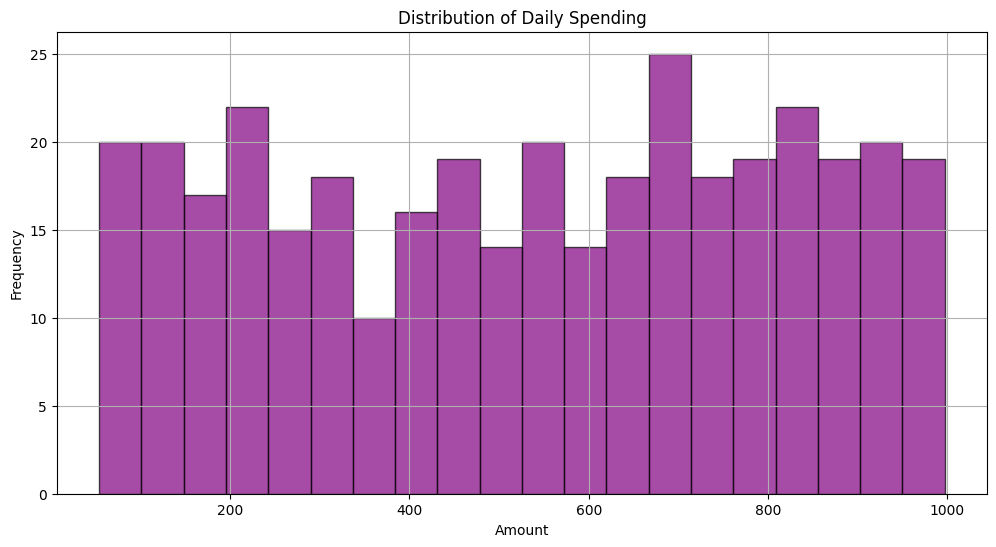

In [72]:
# Visualization 3: Daily Spending Histogram
plt.figure(figsize=(12, 6))
plt.hist(df['amount'], bins=20, color='purple', edgecolor='black', alpha=0.7)
plt.title('Distribution of Daily Spending')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.grid()
plt.show()

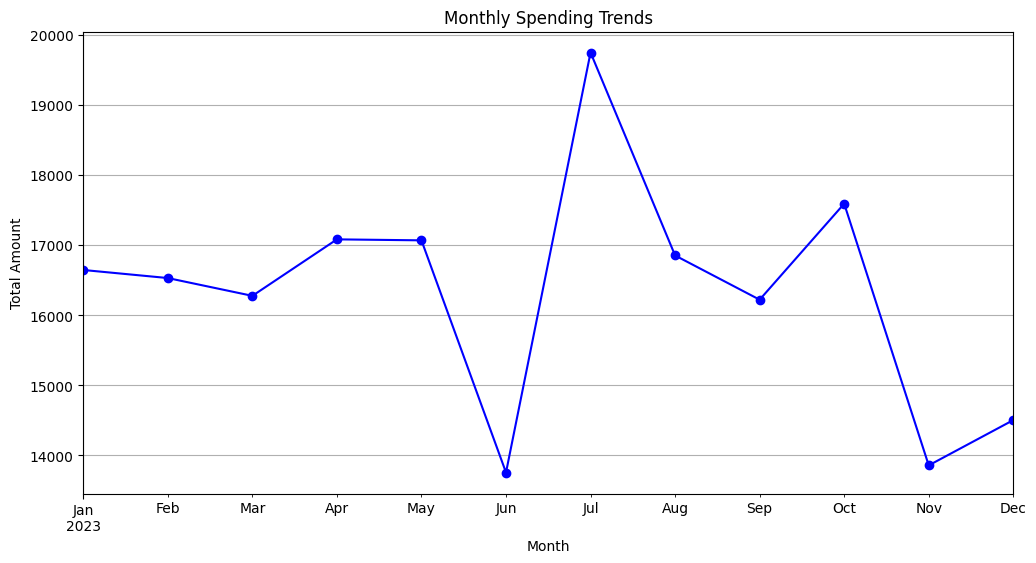

In [73]:
# Visualization 4: Monthly Spending Line Chart
df['month'] = df['date'].dt.to_period('M')
monthly_sum = df.groupby('month')['amount'].sum()

plt.figure(figsize=(12, 6))
monthly_sum.plot(kind='line', marker='o', color='blue')
plt.title('Monthly Spending Trends')
plt.ylabel('Total Amount')
plt.xlabel('Month')
plt.grid()
plt.show()

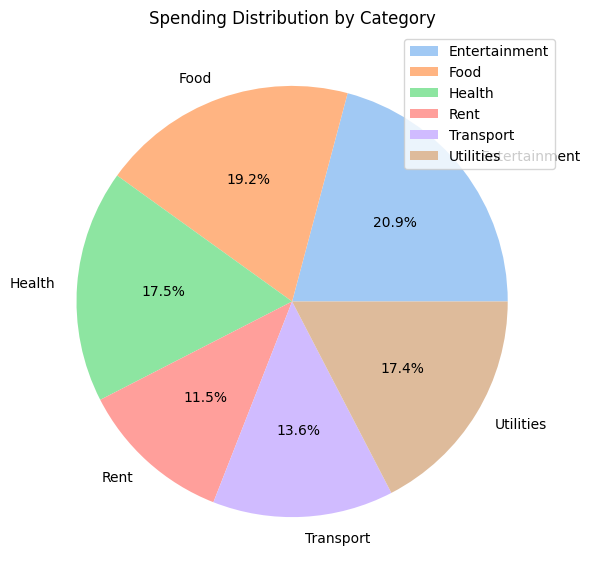

In [74]:
# Visualization 5: Spending by Category Pie Chart
category_sum = df.groupby('category')['amount'].sum()

plt.figure(figsize=(10, 7))
category_sum.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'), legend=True)
plt.title('Spending Distribution by Category')
plt.ylabel('')
plt.show()

C:\Users\Ajinkya Mariche\AppData\Local\Temp\ipykernel_53236\2166772525.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_spending_days['date'].dt.strftime('%Y-%m-%d'), y=top_spending_days['amount'], palette='viridis')


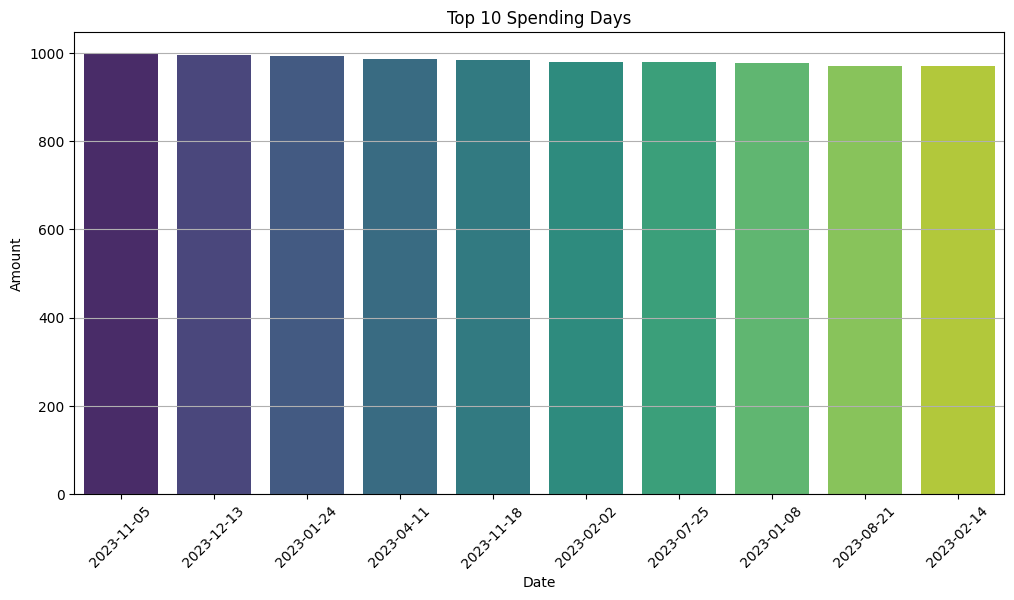

In [75]:
# Visualization 6: Top 10 Spending Days
top_spending_days = df.nlargest(10, 'amount')

plt.figure(figsize=(12, 6))
sns.barplot(x=top_spending_days['date'].dt.strftime('%Y-%m-%d'), y=top_spending_days['amount'], palette='viridis')
plt.title('Top 10 Spending Days')
plt.ylabel('Amount')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


In [76]:
# Predicted Monthly Spending
total_predicted_spending = np.sum(future_predictions)
print(f"Predicted total spending for the next month: ₹{total_predicted_spending:.2f}")

Predicted total spending for the next month: ₹15189.01
